# Extract the data from the predictor raster variables for the Validation dataset

In [1]:
from pyspatialml import Raster # Library for working with geospatial rasters (bands, stacks)
import os # Library for interacting with the operating system (e.g., changing directories)
import matplotlib.pyplot as plt # Library for creating static, interactive, and animated visualizations (plotting)
import matplotlib as mpl # Matplotlib library for setting global plot styles
import geopandas # Library for working with geospatial vector data (shapefiles)
import pandas as pd # Library for data manipulation and analysis (DataFrames)
import seaborn as sn # Library for statistical data visualization (not explicitly used here)
import rasterio.plot # Utility for plotting raster data
import numpy as np # Library for efficient numerical operations and array handling

Setting up the directiry path

In [2]:
os.chdir(r'/workspace/MCC') # Set the current working directory to the 'MCC' external validation area data folder.

Choosing all the predictors

In [3]:
# This list defines all the environmental factors (rasters) for the MCC validation area.
# These predictors must match the predictor set used for the VY training area.
predictors = ['elevation.tif', 'lulc.tif', 'ndvi.tif', 'ndwi.tif', 'river.tif', 'road.tif', 'lithology.tif', 'lithology_boundary.tif', 'fault.tif', 'twi.tif', 'spi.tif', 'tri.tif','roughness.tif', 'slope.tif', 'aspect.tif', 'profile.tif','planform.tif']

In [4]:
print(f"Number of predictor: {len(predictors)}") # Print the total count of predictor variables to confirm the list length.



Number of predictor: 18


Making a raster stack of all the predictors. The predictors have the same extent, projection and resolution


In [5]:
stack = Raster(predictors) # Create a Raster stack object from the GeoTIFF files. This stacks all environmental layers together for efficient sampling.

Checking the bands in our stack


In [6]:
stack.names # Display the names of the layers (bands) in the created raster stack. This confirms the order and names of the features.

dict_keys(['elevation', 'lulc', 'ndvi', 'ndwi', 'river', 'road', 'lithology', 'lithology_boundary', 'fault', 'twi', 'spi', 'tri', 'tpi', 'roughness', 'slope', 'aspect', 'profile', 'planform'])

Reading the shapefile with landslide (centroids)/nonlandslide (randomly created) points and showing the first five rows

In [7]:
training_pt = geopandas.read_file(r"/workspace/shape_files/MCC/sample_points.shp") # Load the vector file (shapefile) containing the landslide presence/absence points for the MCC area.
training_pt.head(5) # Display the first five rows of the Geopandas DataFrame, showing point coordinates and the 'Landslide' label.

,ID,Landslide,geometry
0,1,0,POINT (400515.284 2420848.298)
1,2,0,POINT (401417.396 2416631.050)
2,3,0,POINT (395474.734 2410467.545)
3,4,0,POINT (386869.427 2419814.344)
4,5,0,POINT (403537.896 2422633.924)


Plotting the landslide/non-landslide points on the background of the DEM


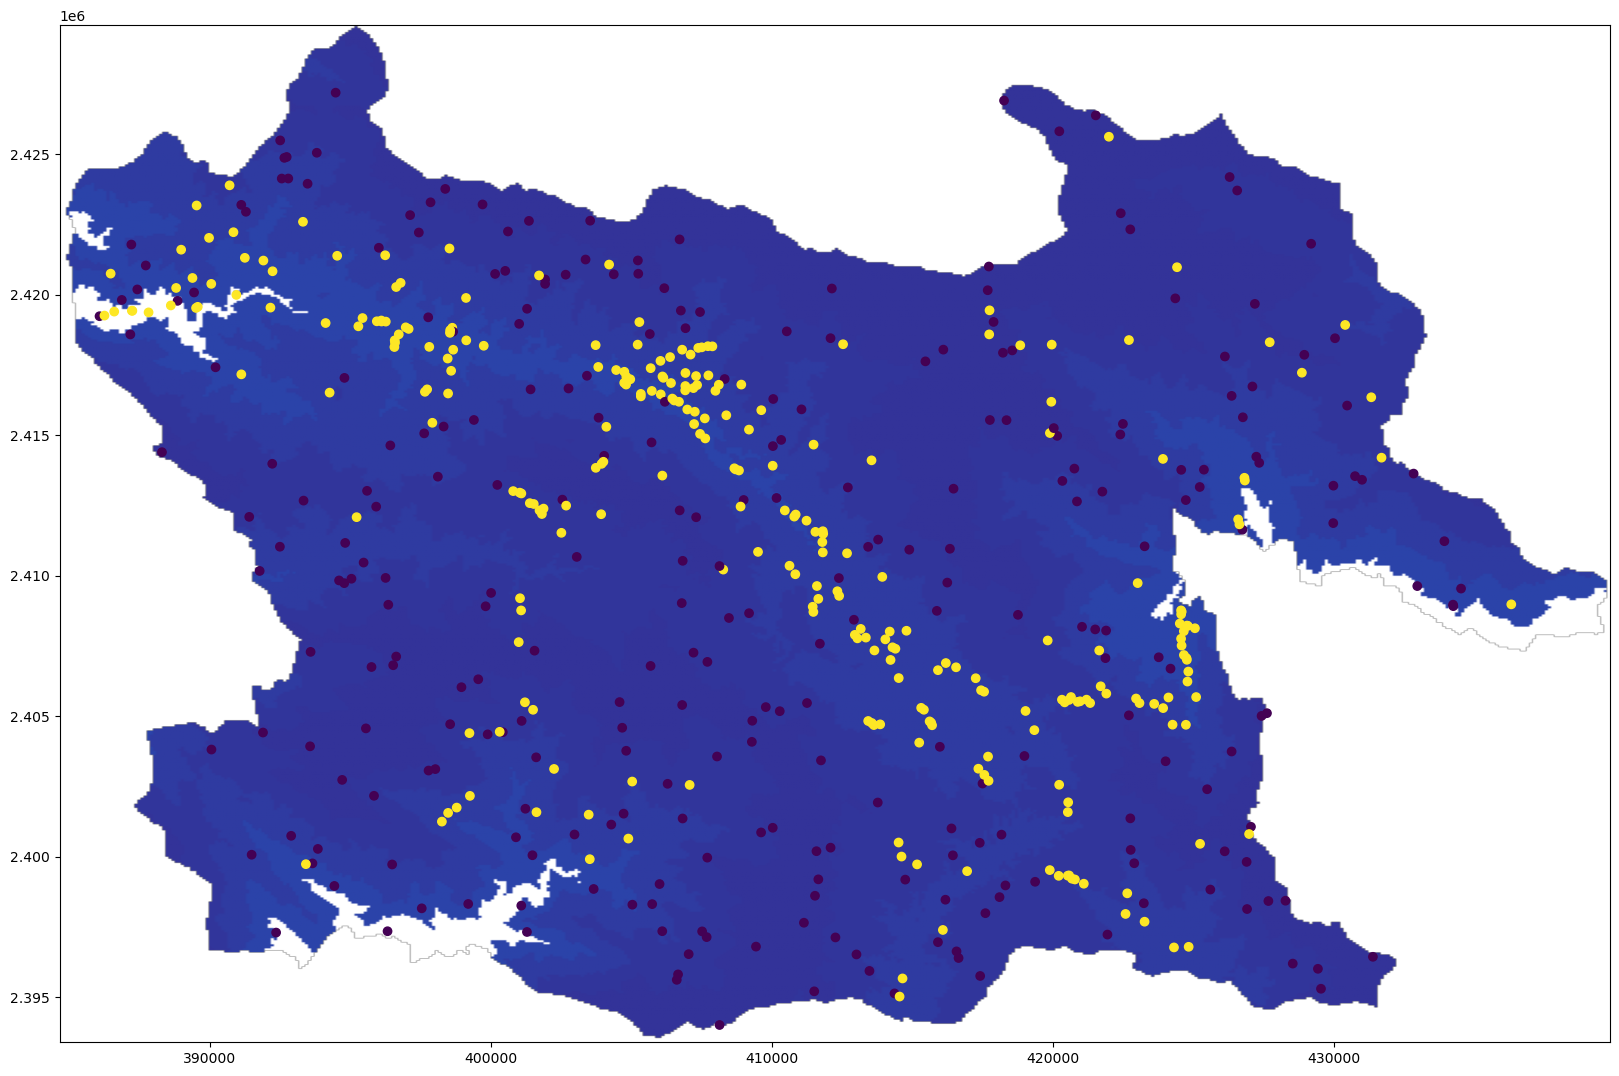

In [8]:
fig, ax = plt.subplots(figsize=(20, 20)) # Create a large figure and axes for visualization.
stack.elevation.plot(ax=ax, cmap='terrain') # Plot the 'elevation.tif' band from the stack as the background (base map) using a terrain color scheme.
training_pt.plot(column="Landslide", ax=ax) # Overlay the sample points onto the elevation map, coloring them based on the 'Landslide' class label.
plt.show() # Display the plot showing the point distribution over the topography.

Extracting the predictor features from the raster stack to our points


In [9]:
df_points = stack.extract_vector(training_pt) # **Core Sampling Step:** For every point in 'training_pt', this function queries and extracts the pixel value from all 17 layers in the 'stack'.
                                            # The resulting DataFrame links each point index to its predictor values.

Showing the first five rows


In [10]:
df_points.head(5) # Display the extracted data. Each row now contains the values for 'elevation', 'lulc', 'slope', etc., at that point's location.

,,elevation,lulc,ndvi,ndwi,river,road,lithology,lithology_boundary,fault,twi,spi,tri,tpi,roughness,slope,aspect,profile,planform,geometry
pixel_idx,geometry_idx,,,,,,,,,,,,,,,,,,,
0,0,0.391,0.697,0.530,1.434,0.625,2.360,0.825,83.720001,0.746,0.908,0.751,1.12,0.19,1.16,1.29,0.886,0.832,0.941,POINT (400515.284 2420848.298)
1,1,1.107,0.697,1.132,1.434,1.268,0.372,0.825,83.720001,1.031,1.113,0.864,1.12,0.28,1.16,1.29,0.839,1.110,0.941,POINT (401417.396 2416631.050)
2,2,1.107,0.697,0.530,0.445,1.268,2.360,0.825,83.720001,1.031,1.047,1.080,1.12,0.28,1.16,1.85,1.217,0.832,1.030,POINT (395474.734 2410467.545)
3,3,1.966,0.697,0.530,1.434,1.026,0.372,0.825,83.720001,1.031,0.908,1.080,1.12,0.19,1.16,1.29,0.886,0.835,0.941,POINT (386869.427 2419814.344)
4,4,0.094,0.697,0.530,0.683,1.026,0.200,0.825,7.780000,1.031,0.810,0.864,1.12,0.20,1.16,1.29,1.383,0.835,0.941,POINT (403537.896 2422633.924)


Merging the data frame back with the class

In [11]:
# Merge the extracted predictor values with the original landslide presence/absence label.
df_points = df_points.merge(
    right=training_pt.loc[:, ["Landslide"]], # The 'Landslide' class label column from the original points (the target variable).
    left_on="geometry_idx", # Column in the left (extracted) DataFrame that holds the point's index.
    right_on="index", # Column in the right (original) DataFrame that holds the index.
    right_index=True # Ensures the merge aligns correctly using the indices.
)

In [12]:
df_points.head(5) # Display the merged DataFrame, which is the final structure for machine learning: Features + Label.

,,elevation,lulc,ndvi,ndwi,river,road,lithology,lithology_boundary,fault,twi,spi,tri,tpi,roughness,slope,aspect,profile,planform,geometry,Landslide
pixel_idx,geometry_idx,,,,,,,,,,,,,,,,,,,,
0,0,0.391,0.697,0.530,1.434,0.625,2.360,0.825,83.720001,0.746,0.908,0.751,1.12,0.19,1.16,1.29,0.886,0.832,0.941,POINT (400515.284 2420848.298),0
1,1,1.107,0.697,1.132,1.434,1.268,0.372,0.825,83.720001,1.031,1.113,0.864,1.12,0.28,1.16,1.29,0.839,1.110,0.941,POINT (401417.396 2416631.050),0
2,2,1.107,0.697,0.530,0.445,1.268,2.360,0.825,83.720001,1.031,1.047,1.080,1.12,0.28,1.16,1.85,1.217,0.832,1.030,POINT (395474.734 2410467.545),0
3,3,1.966,0.697,0.530,1.434,1.026,0.372,0.825,83.720001,1.031,0.908,1.080,1.12,0.19,1.16,1.29,0.886,0.835,0.941,POINT (386869.427 2419814.344),0
4,4,0.094,0.697,0.530,0.683,1.026,0.200,0.825,7.780000,1.031,0.810,0.864,1.12,0.20,1.16,1.29,1.383,0.835,0.941,POINT (403537.896 2422633.924),0


Dropping the "Geometry" column


In [13]:
df_points.to_csv('sample_points.csv', index = False) # Save the current DataFrame (including the geometry column) to a specific CSV file.

In [14]:
data= df_points.drop(columns=['geometry']) # Create the final 'data' DataFrame for analysis by removing the 'geometry' column (coordinates are not needed for ML training).

Decribing the data

In [15]:
data.describe() # Calculate and display descriptive statistics (mean, std dev, min, max, quartiles) for all features in the MCC dataset.

,elevation,lulc,ndvi,ndwi,river,road,lithology,lithology_boundary,fault,twi,spi,tri,tpi,roughness,slope,aspect,profile,planform,Landslide
count,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,569.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,572.000000,570.000000,570.000000,572.000000
mean,2.354037,1.272965,1.251149,1.084206,1.033107,1.554650,1.079851,76.613707,1.008486,0.995598,0.990598,1.119301,0.253077,1.136084,1.189668,1.029131,1.021623,1.012984,0.500000
std,9.910948,1.074756,0.965205,0.588377,0.255799,1.040375,0.390778,22.497581,0.148521,0.103580,0.137536,0.264528,0.058038,0.285051,0.315733,0.253285,0.175414,0.136495,0.500438
min,0.094000,0.697000,0.530000,0.445000,0.444000,0.104000,0.825000,4.060000,0.746000,0.810000,0.751000,0.400000,0.190000,0.560000,0.710000,0.653000,0.832000,0.941000,0.000000
25%,0.391000,0.697000,0.530000,0.683000,0.983000,0.200000,0.825000,83.720001,1.031000,0.908000,0.864000,1.120000,0.190000,1.160000,0.880000,0.839000,0.832000,0.941000,0.000000
50%,1.107000,0.697000,1.132000,1.434000,1.026000,2.360000,0.825000,83.720001,1.031000,1.047000,1.080000,1.120000,0.280000,1.160000,1.290000,0.980000,1.110000,1.030000,0.500000
75%,1.107000,2.225000,1.350250,1.434000,1.268000,2.360000,1.678000,83.720001,1.138000,1.091000,1.080000,1.120000,0.330000,1.160000,1.290000,1.383000,1.110000,1.030000,1.000000
max,69.867996,6.568000,5.061000,8.408000,1.268000,2.360000,1.678000,83.720001,1.138000,1.113000,1.230000,2.020000,0.330000,2.120000,1.850000,1.383000,1.277000,1.651000,1.000000


Cheking the data types in the columns and missing values


In [16]:
data.info() # Display a summary of the DataFrame structure, including column names, data types, and checking for any missing (null) values.

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 572 entries, (0, 0) to (571, 571)
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   elevation           572 non-null    float64
 1   lulc                572 non-null    float64
 2   ndvi                572 non-null    float64
 3   ndwi                572 non-null    float64
 4   river               572 non-null    float64
 5   road                572 non-null    float64
 6   lithology           569 non-null    float64
 7   lithology_boundary  572 non-null    float64
 8   fault               572 non-null    float64
 9   twi                 572 non-null    float64
 10  spi                 572 non-null    float64
 11  tri                 572 non-null    float64
 12  tpi                 572 non-null    float64
 13  roughness           572 non-null    float64
 14  slope               572 non-null    float64
 15  aspect              572 non-null    float64
 

Saving data as a .csv file for later use

In [17]:
data.to_csv('sample_points.csv', index = False) # Save the clean, finalized MCC dataset to 'sample_points.csv'. This file will be loaded for external validation in subsequent notebooks.

End.